# 📱 Smartphone Recommendation — แนะนำสมาร์ตโฟน



## 1. โจทย์

กลุ่มเพื่อน 5 คนกำลังคุยกันเรื่องมือถือ แต่ละคนมีรุ่นที่ชอบไม่เหมือนกัน ถ้าเรารู้ว่าใครชอบรุ่นไหน เราจะลองดูว่าคนที่ชอบคล้าย ๆ กันเลือกรุ่นอะไรอีกบ้าง แล้วเอารุ่นนั้นมาแนะนำให้อีกคน


คนในกลุ่มของมี 5 คน

```
Narin
Ploy
Bank
Fah
Krit
```

มือถือที่พวกเขาคุยกันมี 10 รุ่น

```
iPhone 16
iPhone 16 Pro
Samsung Galaxy S25
Samsung Galaxy S25 Ultra
Samsung Galaxy A56 5G
Xiaomi 15
OPPO Find X8 Pro
vivo X200 Pro
Google Pixel 9 Pro
OnePlus 13
```

แต่พอไปดูจริง ๆ ในกลุ่มนี้ไม่มีใครเลือก Samsung Galaxy S25 Ultra, Samsung Galaxy A56 5G และ OnePlus 13 เลย รุ่นพวกนี้ก็ยังเก็บไว้ในข้อมูลเหมือนเดิม (จะไปโผล่อีกทีตอนใส่ราคากับสเปกด้านล่าง) แต่จะไม่ถูกวาดในกราฟหลัก เพราะไม่มีเส้นเชื่อมกับใครเลย ถ้าวาดไปด้วยก็จะเป็นจุดลอยไม่มีประโยชน์

## 2. ใครชอบรุ่นไหนบ้าง

ตั้งข้อมูลสมมติไว้แบบนี้

```
Narin → iPhone 16
Narin → Samsung Galaxy S25

Bank  → iPhone 16
Bank  → Samsung Galaxy S25
Bank  → Xiaomi 15

Ploy  → Samsung Galaxy S25
Ploy  → Xiaomi 15
Ploy  → OPPO Find X8 Pro

Fah   → iPhone 16 Pro
Fah   → Google Pixel 9 Pro

Krit  → Google Pixel 9 Pro
Krit  → vivo X200 Pro
Krit  → OPPO Find X8 Pro
```

จะเห็นว่า **Narin กับ Bank** ชอบมือถือรุ่นเดียวกันถึง 2 รุ่น (iPhone 16 และ Samsung Galaxy S25) ส่วน Bank ยังชอบ **Xiaomi 15** เพิ่มอีกรุ่นที่ Narin ยังไม่มี

พอมองแบบนี้ก็พอเดาได้ว่า

```
Narin
 ↓
ชอบมือถือร่วมกับ Bank อยู่ 2 รุ่น
 ↓
Bank ยังชอบ Xiaomi 15 เพิ่ม
 ↓
Narin ยังไม่ได้เลือก Xiaomi 15
 ↓
เลยลองแนะนำ Xiaomi 15 ให้ Narin
```

ส่วน Ploy, Fah และ Krit เราตั้งให้เชื่อมกันคนละทาง ไม่ให้กระจุกอยู่แค่คู่ Narin-Bank คู่เดียว เดี๋ยวลองดูกันว่า Graph จะพาไปเจอใครบ้าง

## 3. Graph หน้าตาเป็นยังไง

ในกราฟนี้ฝั่งหนึ่งเป็น **User** (คนในกลุ่ม) อีกฝั่งเป็น **Smartphone** ส่วนเส้นที่เชื่อมระหว่างกันหมายถึง User คนนั้นชอบมือถือรุ่นนั้น ไม่มีเส้นเชื่อมระหว่าง User กับ User หรือ Smartphone กับ Smartphone โดยตรง

ถ้าเขียนเป็น NetworkX ก็แค่

```python
G.add_edge("Narin", "iPhone 16")
```

เริ่มเลย ใช้ Google Colab

In [ ]:
!pip -q install networkx

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter

## 4. สร้าง Graph ด้วย NetworkX

In [ ]:
G = nx.Graph()

เอา User ทั้ง 5 คนใส่เข้าไปก่อน

In [ ]:
users = [
    "Narin",
    "Ploy",
    "Bank",
    "Fah",
    "Krit"
]

for user in users:
    G.add_node(
        user,
        node_type="user"
    )

แล้วใส่มือถือ 10 รุ่นเข้าไป

In [ ]:
smartphones = [
    "iPhone 16",
    "iPhone 16 Pro",
    "Samsung Galaxy S25",
    "Samsung Galaxy S25 Ultra",
    "Samsung Galaxy A56 5G",
    "Xiaomi 15",
    "OPPO Find X8 Pro",
    "vivo X200 Pro",
    "Google Pixel 9 Pro",
    "OnePlus 13"
]

for phone in smartphones:
    G.add_node(
        phone,
        node_type="smartphone"
    )

ต่อไปคือใส่เส้นเชื่อมตามข้อมูลความชอบที่วางไว้ในหัวข้อที่ 2

In [ ]:
likes = [
    ("Narin", "iPhone 16"),
    ("Narin", "Samsung Galaxy S25"),

    ("Bank", "iPhone 16"),
    ("Bank", "Samsung Galaxy S25"),
    ("Bank", "Xiaomi 15"),

    ("Ploy", "Samsung Galaxy S25"),
    ("Ploy", "Xiaomi 15"),
    ("Ploy", "OPPO Find X8 Pro"),

    ("Fah", "iPhone 16 Pro"),
    ("Fah", "Google Pixel 9 Pro"),

    ("Krit", "Google Pixel 9 Pro"),
    ("Krit", "vivo X200 Pro"),
    ("Krit", "OPPO Find X8 Pro")
]

G.add_edges_from(likes)

print("จำนวน Node ทั้งหมด:", G.number_of_nodes())
print("จำนวน Edge ทั้งหมด:", G.number_of_edges())

จำนวน Node ทั้งหมด: 15
จำนวน Edge ทั้งหมด: 13


## 5. วาด Graph ดูสักหน่อย

ลองวาดออกมาดูภาพรวม ให้ User อยู่ฝั่งซ้าย Smartphone อยู่ฝั่งขวา จะได้เห็นชัดว่าใครเชื่อมกับรุ่นไหนบ้าง ไม่ใช้ layout แบบสุ่มเพราะรูปจะดูรก

รุ่นที่ไม่มีใครเลือกเลย (Galaxy S25 Ultra, A56 5G, OnePlus 13) จะไม่เอามาวาดด้วย เพราะเป็นจุดลอยที่ไม่มีเส้นเชื่อม ดูแล้วไม่ช่วยอะไร

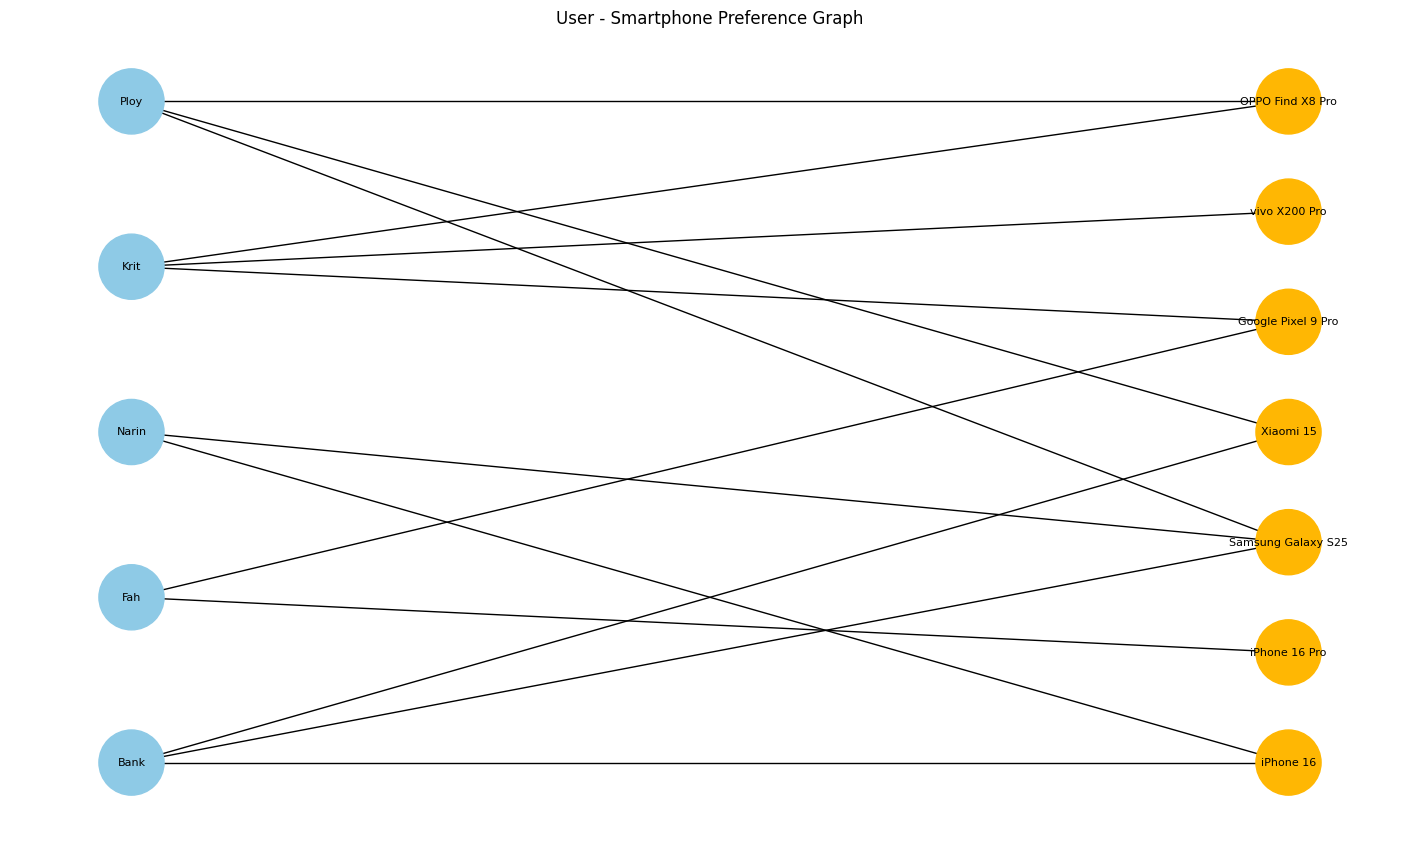

In [ ]:
# เอาแค่ Node ที่มีเส้นเชื่อมจริง ๆ มาวาด (ตัด Smartphone ที่ไม่มีใครเลือกออก)
nodes_with_edges = [n for n in G.nodes() if G.degree(n) > 0]
H = G.subgraph(nodes_with_edges)

plt.figure(figsize=(14, 8))

# จัด Layout แบบสองฝั่ง: User อยู่ซ้าย, Smartphone อยู่ขวา
pos = nx.bipartite_layout(H, users)

node_colors = [
    "#8ecae6" if H.nodes[n]["node_type"] == "user" else "#ffb703"
    for n in H.nodes()
]

nx.draw(
    H,
    pos,
    with_labels=True,
    node_color=node_colors,
    node_size=2200,
    font_size=8
)

plt.title("User - Smartphone Preference Graph")
plt.show()

สีฟ้าฝั่งซ้ายคือคนในกลุ่ม สีส้มฝั่งขวาคือมือถือแต่ละรุ่น เส้นที่โยงกันคือความชอบของแต่ละคน (title ตั้งเป็นภาษาอังกฤษ เพราะฟอนต์ไทยบน Colab ปกติแสดง title เป็นสี่เหลี่ยม ส่วนคำอธิบายเป็น Markdown ใช้ภาษาไทยได้ตามปกติ)

## 6. ลองถามอะไรง่าย ๆ จาก Graph ก่อน

### ข้อ 1: Narin ชอบมือถือรุ่นไหนบ้าง

In [ ]:
narin_phones = list(G.neighbors("Narin"))
print("Narin ชอบ:", narin_phones)

Narin ชอบ: ['iPhone 16', 'Samsung Galaxy S25']


ตรงนี้แค่หา Neighbor ของ Narin ก็ได้คำตอบเลย เพราะ Neighbor ของ Narin ก็คือมือถือทุกรุ่นที่มีเส้นเชื่อมกับ Narin

### ข้อ 2: ใครชอบมือถือคล้าย Narin

In [ ]:
for phone in G.neighbors("Narin"):
    print("มือถือ:", phone)
    for user in G.neighbors(phone):
        if user != "Narin":
            print("   คนที่ชอบเหมือนกัน:", user)

มือถือ: iPhone 16
   คนที่ชอบเหมือนกัน: Bank
มือถือ: Samsung Galaxy S25
   คนที่ชอบเหมือนกัน: Bank
   คนที่ชอบเหมือนกัน: Ploy


จากผลตรงนี้ **Bank** โผล่มาทั้งสองรุ่นเลย แปลว่า Bank คือคนที่รสนิยมใกล้ Narin ที่สุดในกลุ่มนี้ ส่วนคนอื่นยังไม่มีใครชอบรุ่นเดียวกับ Narin เลย

### ข้อ 3: แล้วควรแนะนำรุ่นไหนให้ Narin

จากข้อ 2 เราเห็นว่า Bank ชอบคล้าย Narin และ Bank ยังชอบ **Xiaomi 15** ที่ Narin ยังไม่มี เดาเบื้องต้นได้เลยว่าคำตอบคือ Xiaomi 15 — แต่ทำมือแบบนี้ใช้ได้กับแค่คนเดียว หัวข้อถัดไปเราจะลองทำให้เป็นขั้นตอนที่ใช้ซ้ำได้กับทุกคน

## 7. แนวคิดตอนหาคำแนะนำ

เอาสิ่งที่ทำในข้อ 6 มาต่อเป็นขั้นตอนเดียวกัน แต่ทำกับมือถือทุกรุ่นที่คนนั้นชอบ ไม่ใช่แค่รุ่นเดียว

```
คนที่เราจะแนะนำให้ (Target User)
    ↓
มือถือที่เขาชอบ
    ↓
หาคนอื่นที่ชอบมือถือรุ่นเดียวกัน
    ↓
ดูว่าคนเหล่านั้นชอบมือถือรุ่นอื่นอะไรอีก
    ↓
ตัดรุ่นที่ Target User มีอยู่แล้วออก
    ↓
นับดูว่ารุ่นไหนโผล่มาบ่อยสุด (ใช้ Counter)
    ↓
เรียงจากคะแนนมากไปน้อย
```

พูดง่าย ๆ คือ **ถ้ามีคนที่มีความชอบใกล้กับเราเลือกมือถือรุ่นเดียวกันหลายครั้ง รุ่นนั้นก็จะได้คะแนนแนะนำสูงขึ้น** วิธีนี้เป็นแค่การนับตาม Graph เฉย ๆ ไม่ใช่โมเดลอะไรที่ซับซ้อน

ลองไล่ทำด้วยมือก่อนสักครั้งให้เห็นภาพ ยังไม่ห่อเป็นฟังก์ชัน

In [ ]:
target_user = "Narin"

recommendations = Counter()

# มือถือที่ Narin ชอบอยู่แล้ว
liked_phones = set(G.neighbors(target_user))
print("Narin ชอบอยู่แล้ว:", liked_phones)

for phone in liked_phones:
    # หาคนอื่นที่ชอบมือถือรุ่นเดียวกัน
    for similar_user in G.neighbors(phone):
        if similar_user == target_user:
            continue

        # ดูว่าคนนั้นชอบรุ่นอื่นอะไรอีก
        for other_phone in G.neighbors(similar_user):
            if other_phone not in liked_phones:
                recommendations[other_phone] += 1

print("ผลลัพธ์:", recommendations)

Narin ชอบอยู่แล้ว: {'iPhone 16', 'Samsung Galaxy S25'}
ผลลัพธ์: Counter({'Xiaomi 15': 3, 'OPPO Find X8 Pro': 1})


**Xiaomi 15** ได้คะแนนสูงสุด (3 คะแนน) มาจากสองคน คือ Bank ที่ชอบเหมือน Narin ทั้งทาง iPhone 16 และ Samsung Galaxy S25 เลยถูกนับ 2 ครั้ง กับ Ploy ที่ชอบเหมือน Narin ทาง Samsung Galaxy S25 อีก 1 ครั้ง ส่วน **OPPO Find X8 Pro** ได้แค่ 1 คะแนน มาจาก Ploy คนเดียว ที่ชอบร่วมกับ Narin แค่รุ่นเดียว (Samsung Galaxy S25) แล้ว Ploy ก็ชอบ OPPO Find X8 Pro เพิ่ม

## 8. เอามาห่อเป็นฟังก์ชัน

In [ ]:
def recommend_smartphones(G, target_user):
    """
    แนะนำมือถือให้ target_user จากคนที่มีความชอบใกล้เคียงกันใน Graph
    คืนค่าเป็น Counter เรียงจากคะแนนสูงไปต่ำ
    """
    recommendations = Counter()

    liked_phones = set(G.neighbors(target_user))

    for phone in liked_phones:
        for similar_user in G.neighbors(phone):
            if similar_user == target_user:
                continue

            for other_phone in G.neighbors(similar_user):
                if other_phone not in liked_phones:
                    recommendations[other_phone] += 1

    return recommendations

## 9. ลองเรียกใช้กับหลาย ๆ คน

In [ ]:
result_narin = recommend_smartphones(G, "Narin")
print("แนะนำให้ Narin:", result_narin.most_common())

แนะนำให้ Narin: [('Xiaomi 15', 3), ('OPPO Find X8 Pro', 1)]


In [ ]:
result_bank = recommend_smartphones(G, "Bank")
print("แนะนำให้ Bank:", result_bank.most_common())

แนะนำให้ Bank: [('OPPO Find X8 Pro', 2)]


In [ ]:
result_ploy = recommend_smartphones(G, "Ploy")
print("แนะนำให้ Ploy:", result_ploy.most_common())

แนะนำให้ Ploy: [('iPhone 16', 3), ('Google Pixel 9 Pro', 1), ('vivo X200 Pro', 1)]


In [ ]:
result_fah = recommend_smartphones(G, "Fah")
print("แนะนำให้ Fah:", result_fah.most_common())

แนะนำให้ Fah: [('vivo X200 Pro', 1), ('OPPO Find X8 Pro', 1)]


In [ ]:
result_krit = recommend_smartphones(G, "Krit")
print("แนะนำให้ Krit:", result_krit.most_common())

แนะนำให้ Krit: [('iPhone 16 Pro', 1), ('Samsung Galaxy S25', 1), ('Xiaomi 15', 1)]


แต่ละคนได้คำแนะนำไม่เหมือนกันเลย ตามเส้นทางที่ Graph พาไปเจอ:

- **Narin** ได้ Xiaomi 15 เป็นอันดับหนึ่ง (3 คะแนน) มาจากสองคน คือ Bank ที่มีมือถือร่วมกับ Narin 2 รุ่น (iPhone 16 และ Samsung Galaxy S25) แล้ว Bank ก็ชอบ Xiaomi 15 เพิ่ม เลยถูกนับผ่านทั้งสองรุ่นนั้นรวม 2 คะแนน ส่วนอีก 1 คะแนนมาจาก Ploy ที่มีมือถือร่วมกับ Narin ทาง Samsung Galaxy S25 เหมือนกัน แล้ว Ploy ก็ชอบ Xiaomi 15 ด้วย ส่วน OPPO Find X8 Pro ได้ 1 คะแนน มาจาก Ploy คนเดียว ที่เชื่อมผ่าน Samsung Galaxy S25 แล้วชอบ OPPO Find X8 Pro เพิ่ม
- **Bank** ได้ OPPO Find X8 Pro (2 คะแนน) มาจาก Ploy คนเดียว เพราะ Ploy มีมือถือร่วมกับ Bank 2 รุ่น คือ Samsung Galaxy S25 และ Xiaomi 15 แล้ว Ploy ก็ชอบ OPPO Find X8 Pro เพิ่ม เลยถูกนับผ่านทั้งสองรุ่นนั้นรวม 2 คะแนน
- **Ploy** ได้ iPhone 16 เป็นอันดับหนึ่ง (3 คะแนน) มาจากสองคน คือ Narin ที่มีมือถือร่วมกับ Ploy ทาง Samsung Galaxy S25 แล้ว Narin ก็ชอบ iPhone 16 (1 คะแนน) และ Bank ที่มีมือถือร่วมกับ Ploy 2 รุ่น คือ Samsung Galaxy S25 และ Xiaomi 15 แล้ว Bank ก็ชอบ iPhone 16 เหมือนกัน เลยถูกนับผ่านทั้งสองรุ่นนั้นรวม 2 คะแนน (รวมเป็น 3 คะแนน) ส่วน Google Pixel 9 Pro กับ vivo X200 Pro ได้ 1 คะแนนเท่ากัน มาจาก Krit ที่มีมือถือร่วมกับ Ploy ทาง OPPO Find X8 Pro แล้ว Krit ก็ชอบทั้งสองรุ่นนี้เพิ่ม
- **Fah** ได้ vivo X200 Pro และ OPPO Find X8 Pro (1 คะแนนเท่ากัน) มาจาก Krit คนเดียว ที่มีมือถือร่วมกับ Fah ทาง Google Pixel 9 Pro แล้ว Krit ก็ชอบทั้งสองรุ่นนี้เพิ่ม
- **Krit** ได้ iPhone 16 Pro (1 คะแนน) มาจาก Fah ที่มีมือถือร่วมกับ Krit ทาง Google Pixel 9 Pro แล้ว Fah ก็ชอบ iPhone 16 Pro เพิ่ม ส่วน Samsung Galaxy S25 กับ Xiaomi 15 ได้ 1 คะแนนเท่ากัน มาจาก Ploy ที่มีมือถือร่วมกับ Krit ทาง OPPO Find X8 Pro แล้ว Ploy ก็ชอบทั้งสองรุ่นนี้เพิ่ม

## 10. ใส่ข้อมูลของมือถือแต่ละรุ่นเพิ่ม

Node ใน Graph ไม่ได้เก็บได้แค่ชื่ออย่างเดียว เราใส่ข้อมูลประกอบเข้าไปได้ด้วย เช่น ยี่ห้อ ราคา ระบบปฏิบัติการ RAM ที่เก็บข้อมูล และเหมาะกับใช้งานแบบไหน

ราคาที่ใส่ไว้เป็นราคาตัวอย่างที่ใช้ประกอบการทดลองเท่านั้น ไม่ได้อ้างอิงราคาขายจริงในตลาด

In [ ]:
phone_specs = {
    "iPhone 16":                {"brand": "Apple",   "price": 29900, "os": "iOS",     "ram": 8,  "storage": 128, "use_case": "Daily Use"},
    "iPhone 16 Pro":            {"brand": "Apple",   "price": 39900, "os": "iOS",     "ram": 8,  "storage": 256, "use_case": "Camera"},
    "Samsung Galaxy S25":       {"brand": "Samsung", "price": 29900, "os": "Android", "ram": 12, "storage": 256, "use_case": "Daily Use"},
    "Samsung Galaxy S25 Ultra": {"brand": "Samsung", "price": 45900, "os": "Android", "ram": 12, "storage": 512, "use_case": "Camera"},
    "Samsung Galaxy A56 5G":    {"brand": "Samsung", "price": 13900, "os": "Android", "ram": 8,  "storage": 128, "use_case": "Daily Use"},
    "Xiaomi 15":                {"brand": "Xiaomi",  "price": 27900, "os": "Android", "ram": 12, "storage": 256, "use_case": "Gaming"},
    "OPPO Find X8 Pro":         {"brand": "OPPO",    "price": 32900, "os": "Android", "ram": 12, "storage": 256, "use_case": "Camera"},
    "vivo X200 Pro":            {"brand": "vivo",    "price": 34900, "os": "Android", "ram": 16, "storage": 512, "use_case": "Camera"},
    "Google Pixel 9 Pro":       {"brand": "Google",  "price": 33900, "os": "Android", "ram": 12, "storage": 128, "use_case": "Camera"},
    "OnePlus 13":               {"brand": "OnePlus", "price": 31900, "os": "Android", "ram": 16, "storage": 256, "use_case": "Gaming"}
}

for phone, specs in phone_specs.items():
    G.nodes[phone].update(specs)

# ลองเช็คดูสักรุ่น
print(G.nodes["Xiaomi 15"])

{'node_type': 'smartphone', 'brand': 'Xiaomi', 'price': 27900, 'os': 'Android', 'ram': 12, 'storage': 256, 'use_case': 'Gaming'}


## 11. กรองคำแนะนำด้วยงบที่มี

พอมี Property เรื่องราคาแล้ว เราเอามากรองผลลัพธ์ต่อได้เลย เช่น ถ้า Narin มีงบไม่เกิน 30,000 บาท รุ่นที่แพงกว่างบก็ไม่ควรถูกแนะนำ

ตรงนี้แค่เทียบราคากับงบตรง ๆ ยังไม่ใช่การให้คะแนนแบบซับซ้อนอะไร

In [ ]:
def recommend_within_budget(G, target_user, budget):
    all_recommendations = recommend_smartphones(G, target_user)

    filtered = Counter({
        phone: score
        for phone, score in all_recommendations.items()
        if G.nodes[phone]["price"] <= budget
    })

    return filtered

In [ ]:
narin_budget = 30000

result_narin_budget = recommend_within_budget(G, "Narin", narin_budget)

print(f"งบของ Narin: {narin_budget} บาท")
print("แนะนำให้ Narin (ในงบ):", result_narin_budget.most_common())

งบของ Narin: 30000 บาท
แนะนำให้ Narin (ในงบ): [('Xiaomi 15', 3)]


OPPO Find X8 Pro ราคาเกินงบของ Narin ไปหน่อย เลยถูกกรองออก เหลือแค่ Xiaomi 15 ซึ่งก็เป็นตัวเลือกที่คะแนนสูงสุดอยู่แล้ว งบที่ตั้งไว้เลยไม่ได้ทำให้ผลลัพธ์เปลี่ยนไปจากเดิมมาก